# Refinement loss (material-point metric) across episodes: octopus / turtle / tp_roll

One figure, one row per PokeFlex episode, scored with the **correspondence loss**
(`TrackedCorrespondenceLoss`, see `refinement_loss_correspondence.ipynb`): each sim surface vertex is paired
once, at the first recorded frame, with the closest point on the reference surface and thereafter compared with
where that material point went, on displacement from the first frame. Only vertices present at the first frame
are scored, so refinement cannot move the metric by adding vertices, and tangential motion (sliding, slip under
the poker) is charged.

Left column: against the episode's tracked dataset surface (rigid detrend, pairs within 10 mm of the poker
skipped). Right column: against the fine-mesh simulation of the same episode, isolating discretisation error.
Dice is left out (its refinement setting differs and is not comparable, see `refinement_loss_episodes.ipynb`).

Recordings: octopus from the benchmark sweeps (`sweep_refine_geometric_work/`, `sweep_refine_legacy_work/`);
turtle and tp_roll from `refinement_loss_runs/` (`sim_octopus --episode <ep> --mesh coarse -gplr --energy neohookean`,
with and without `-r --refine-scoring geometric --refine-geometric-threshold 2 --refine-min-edge-length 0.004`).
3 repeats each; curves are the mean over repeats, the wash the min–max band. The octopus curves are read from
`refinement_loss_correspondence_cache.npz` when present. Run from the repository root (or set `WARP_MFEM_ROOT`).

In [1]:
import os, sys, glob, math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path(os.environ.get("WARP_MFEM_ROOT", Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent))
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))
try:  # the tracked-surface loader expects polyscope to be initialised
    import polyscope as ps; ps.init()
except Exception:
    pass
from mfem.refinement.tracked_surface import TrackedSurfaceOverlay
from mfem.refinement.surface_loss import (
    RecordingOverlay, TrackedSurfaceLoss, TrackedCorrespondenceLoss, score_recording, _load_recording,
)
from mfem.refinement.pokeflex_episodes import get_episode

EPISODES = ["octopus", "turtle", "tp_roll"]
EXCLUDE_TOOL_M = 0.01          # tracked-surface reference only
KEY = "corr_mse"
RUN_DIR = ROOT / "refinement_loss_runs"
CACHE = ROOT / "notebooks" / "refinement_loss_correspondence_episodes_cache.npz"
OCTOPUS_CACHE = ROOT / "notebooks" / "refinement_loss_correspondence_cache.npz"

RUNS = {
    "octopus": {
        "with refinement": sorted(p for p in glob.glob(
            "sweep_refine_geometric_work/rec_refine_geometric_threshold=2.0_refine_min_edge_length=0.004*.npz")
            if "tri_contact" not in p),
        "without refinement": sorted(glob.glob("sweep_refine_legacy_work/rec_norefine*.npz")),
    },
}
for e in ("turtle", "tp_roll"):
    RUNS[e] = {
        "with refinement": sorted(glob.glob(str(RUN_DIR / f"{e}_refine_r*.npz"))),
        "without refinement": sorted(glob.glob(str(RUN_DIR / f"{e}_norefine_r*.npz"))),
    }
FINE_REF = {"octopus": "reference_runs/fine_default.npz",
            **{e: str(RUN_DIR / f"{e}_fine.npz") for e in ("turtle", "tp_roll")}}
TRACKED = {e: get_episode(e).tracked_surface_npy() for e in EPISODES}
for e in EPISODES:
    print(f"{e:8s}  refine {len(RUNS[e]['with refinement'])}  norefine {len(RUNS[e]['without refinement'])}  "
          f"fine {'yes' if os.path.exists(FINE_REF[e]) else 'MISSING'}")

[polyscope] Backend: openGL3_glfw -- Loaded openGL version: 4.6 (Core Profile) Mesa 26.1.6-1pop0~1787580452~24.04~a5619ea


octopus   refine 3  norefine 3  fine yes
turtle    refine 3  norefine 3  fine yes
tp_roll   refine 3  norefine 3  fine yes


In [2]:
FINE_LABEL = "fine mesh (no refinement)"

def build_losses(e):
    paths = RUNS[e]["without refinement"] or RUNS[e]["with refinement"]
    start = _load_recording(paths[0])["start_frame"]
    tracked = TrackedSurfaceOverlay(TRACKED[e], alpha=0.0, start_frame=start, detrend="rigid")
    fine = RecordingOverlay(FINE_REF[e])
    return {
        "vs tracking": (TrackedSurfaceLoss(tracked, symmetric=True, exclude_tool_margin=EXCLUDE_TOOL_M), tracked, EXCLUDE_TOOL_M),
        "vs fine simulation": (TrackedSurfaceLoss(fine, symmetric=True), fine, None),
    }

def load_cache(path):
    if path.exists():
        with np.load(path, allow_pickle=True) as d:
            return dict(d["curves"].item())
    return {}

def save_cache(curves):
    CACHE.parent.mkdir(exist_ok=True)
    np.savez_compressed(CACHE, curves=np.array(curves, dtype=object))

# (episode, reference, recording path) -> per-frame loss dict
curves = load_cache(CACHE)
for (ref, p), c in load_cache(OCTOPUS_CACHE).items():      # reuse the octopus notebook's scoring
    curves.setdefault(("octopus", ref, p), c)
for e in EPISODES:
    losses = None
    to_score = [(ref, p) for ref in ("vs tracking", "vs fine simulation") for paths in RUNS[e].values() for p in paths]
    to_score.append(("vs tracking", FINE_REF[e]))
    for ref, p in to_score:
        if not os.path.exists(p) or (e, ref, p) in curves:
            continue
        losses = losses or build_losses(e)
        print(f"scoring [{e}] {os.path.basename(p)}  {ref} ...", flush=True)
        surf_loss, overlay, margin = losses[ref]
        # a fresh correspondence per recording: bind() fixes the pairing to that recording's first frame
        curves[(e, ref, p)] = score_recording(p, surf_loss, corr=TrackedCorrespondenceLoss(overlay, exclude_tool_margin=margin))
        save_cache(curves)
print(f"{len(curves)} curves ready")

39 curves ready


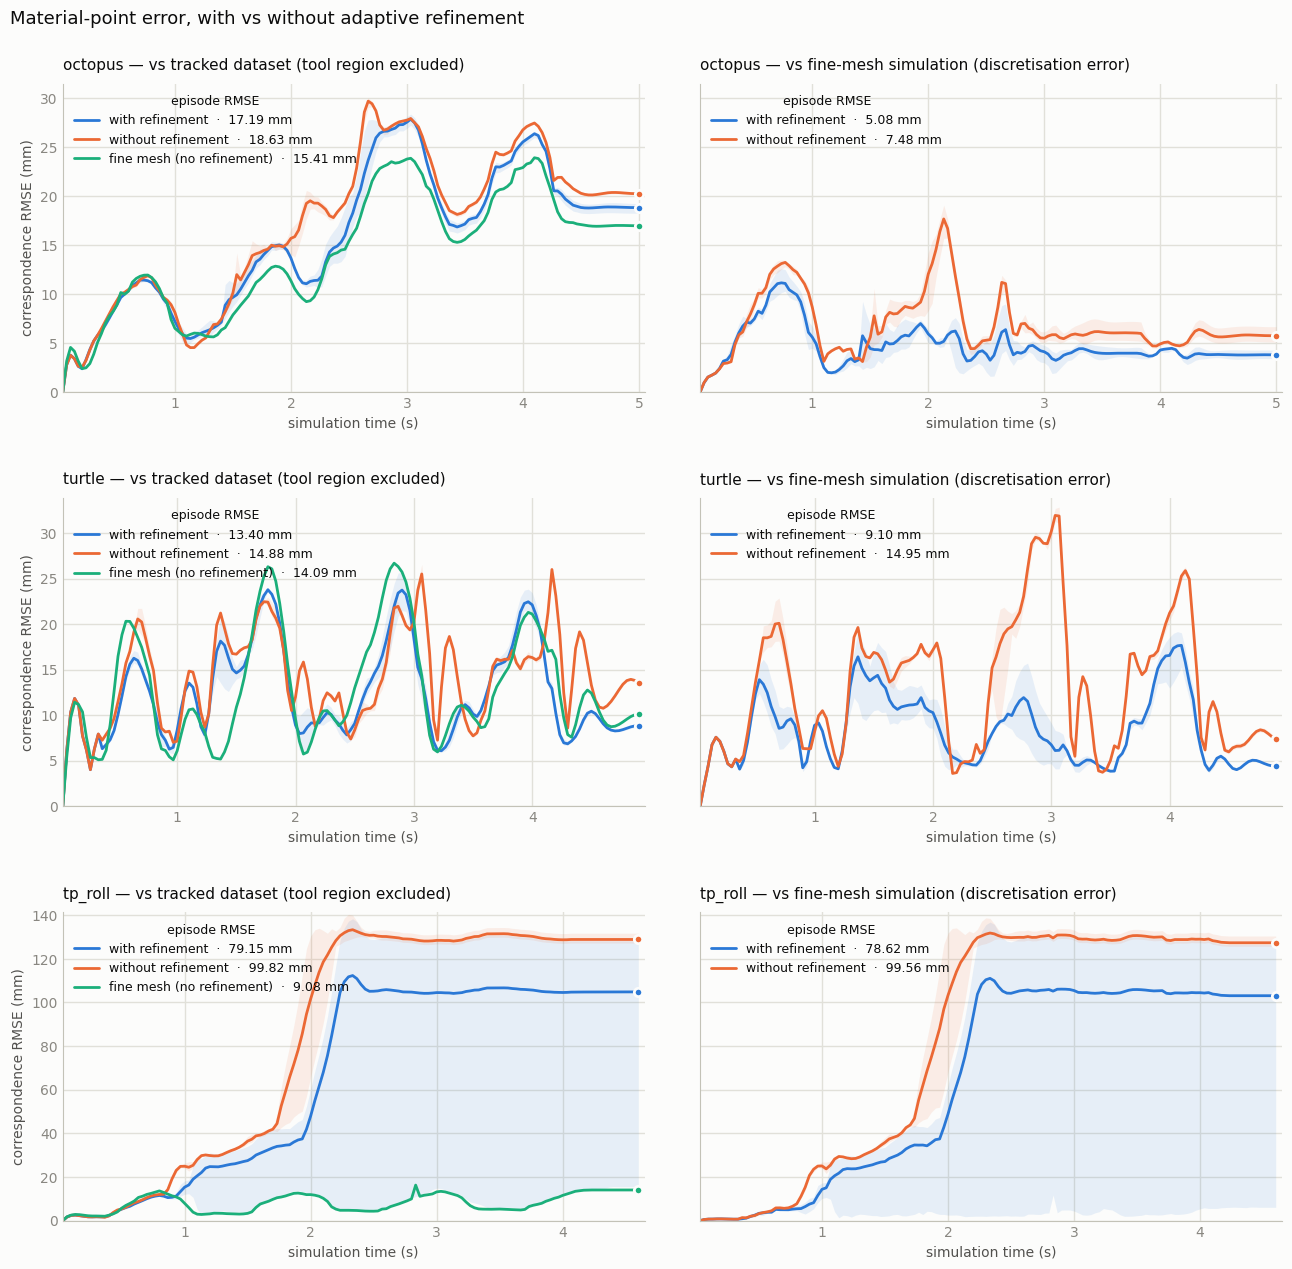

In [3]:
# --- chart style (design-system tokens) ---------------------------------
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
SERIES = {
    "with refinement": "#2a78d6",
    "without refinement": "#eb6834",
    "fine mesh (no refinement)": "#1baf7a",
}
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": AXIS,
    "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 1.0, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

def stack(e, ref, label, key=KEY):
    paths = RUNS[e][label]
    rows = [np.asarray(curves[(e, ref, p)][key], dtype=float) for p in paths]
    n = min(len(r) for r in rows)
    t = np.asarray(curves[(e, ref, paths[0])]["time"], dtype=float)[:n]
    a = np.stack([r[:n] for r in rows])
    return t, a

def episode_rmse_mm(a):
    """RMS over frames and repeats, i.e. sqrt of the sweep's mean-MSE objective."""
    return math.sqrt(a.mean()) * 1e3

def plot_reference(ax, e, ref, title, key=KEY):
    for label in RUNS[e]:
        t, a = stack(e, ref, label, key)
        rmse = np.sqrt(a) * 1e3                       # per repeat, mm
        mean = np.sqrt(a.mean(0)) * 1e3
        c = SERIES[label]
        ax.fill_between(t, rmse.min(0), rmse.max(0), color=c, alpha=0.10, linewidth=0)
        ax.plot(t, mean, color=c, linewidth=2, solid_joinstyle="round", solid_capstyle="round",
                label=f"{label}  ·  {episode_rmse_mm(a):.2f} mm")
        ax.plot([t[-1]], [mean[-1]], "o", ms=6, color=c, markeredgecolor=SURFACE, markeredgewidth=2)
    key_fine = (e, ref, FINE_REF[e])
    if key_fine in curves:                            # single run, no repeat band
        cf = curves[key_fine]
        tf = np.asarray(cf["time"], dtype=float); af = np.asarray(cf[key], dtype=float)[None, :]
        c = SERIES[FINE_LABEL]
        ax.plot(tf, np.sqrt(af[0]) * 1e3, color=c, linewidth=2, solid_joinstyle="round", solid_capstyle="round",
                label=f"{FINE_LABEL}  ·  {episode_rmse_mm(af):.2f} mm")
        ax.plot([tf[-1]], [np.sqrt(af[0, -1]) * 1e3], "o", ms=6, color=c, markeredgecolor=SURFACE, markeredgewidth=2)
    ax.set_title(title, loc="left", fontsize=11, color=INK, pad=10)
    ax.legend(loc="upper left", frameon=False, fontsize=9, title="episode RMSE", title_fontsize=9)
    ax.set_xlabel("simulation time (s)")
    ax.set_xlim(t[0], t[-1] + 0.05)
    ax.set_ylim(0, None)
    ax.tick_params(length=0)

avail = [e for e in EPISODES if RUNS[e]["without refinement"] and RUNS[e]["with refinement"]]
fig, axes = plt.subplots(len(avail), 2, figsize=(13, 4.3 * len(avail)), squeeze=False, sharey="row")
for i, e in enumerate(avail):
    plot_reference(axes[i][0], e, "vs tracking", f"{e} — vs tracked dataset (tool region excluded)")
    plot_reference(axes[i][1], e, "vs fine simulation", f"{e} — vs fine-mesh simulation (discretisation error)")
    axes[i][0].set_ylabel("correspondence RMSE (mm)")
    # sharey="row": size the row to the largest curve in either panel (set_ylim per axis only sees its own)
    top = max(np.nanmax(l.get_ydata()) for ax in axes[i] for l in ax.get_lines())
    axes[i][0].set_ylim(0, top * 1.06)
fig.suptitle("Material-point error, with vs without adaptive refinement", x=0.01, ha="left", fontsize=13, color=INK)
fig.tight_layout(w_pad=4, h_pad=3, rect=(0, 0, 1, 0.98))
fig.savefig(ROOT / "notebooks" / "refinement_loss_correspondence_episodes.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
# Summary: episode RMSE per episode, reference and metric, and the MSE change vs no refinement
rows = []
for e in avail:
    for metric, key in (("correspondence", KEY), ("symmetric surface", "mse_symmetric")):
        for ref in ("vs tracking", "vs fine simulation"):
            base = np.sqrt(stack(e, ref, "without refinement", key)[1].mean())
            key_fine = (e, ref, FINE_REF[e])
            if key_fine in curves:
                af = np.asarray(curves[key_fine][key], dtype=float)
                rows.append({"episode": e, "metric": metric, "reference": ref, "run": FINE_LABEL,
                             "episode RMSE mm": episode_rmse_mm(af), "repeat spread mm": "single run",
                             "MSE change vs no refinement": f"{(af.mean() / base**2 - 1) * 100:+.0f}%"})
            for label in RUNS[e]:
                t, a = stack(e, ref, label, key)
                per_repeat = np.sqrt(a.mean(1)) * 1e3
                rows.append({
                    "episode": e, "metric": metric, "reference": ref, "run": label,
                    "episode RMSE mm": episode_rmse_mm(a),
                    "repeat spread mm": f"{per_repeat.min():.2f} – {per_repeat.max():.2f}",
                    "MSE change vs no refinement": f"{(a.mean() / base**2 - 1) * 100:+.0f}%",
                })
pd.set_option("display.width", 200)
pd.DataFrame(rows).round(2)

,episode,metric,reference,run,episode RMSE mm,repeat spread mm,MSE change vs no refinement
0,octopus,correspondence,vs tracking,fine mesh (no refinement),15.41,single run,-32%
1,octopus,correspondence,vs tracking,with refinement,17.19,16.69 – 17.75,-15%
2,octopus,correspondence,vs tracking,without refinement,18.63,18.54 – 18.80,+0%
3,octopus,correspondence,vs fine simulation,with refinement,5.08,4.52 – 5.47,-54%
4,octopus,correspondence,vs fine simulation,without refinement,7.48,7.31 – 7.65,+0%
5,octopus,symmetric surface,vs tracking,fine mesh (no refinement),7.06,single run,-16%
6,octopus,symmetric surface,vs tracking,with refinement,7.13,6.94 – 7.32,-15%
7,octopus,symmetric surface,vs tracking,without refinement,7.72,7.68 – 7.79,+0%
8,octopus,symmetric surface,vs fine simulation,with refinement,3.69,3.53 – 3.82,-31%
9,octopus,symmetric surface,vs fine simulation,without refinement,4.44,4.38 – 4.54,-0%
